In [1]:
import mdtraj as md
import numpy as np
import scipy
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from itertools import combinations
import sys, os, re
from msmbuilder.decomposition import tICA as msm_tICA
from msmbuilder.featurizer import AtomPairsFeaturizer

sys.path.append(os.path.dirname(os.getcwd())) 
import amuset_tica

In [4]:
# ============================================================
# 1. Core regression: fit M from K(t+1) ≈ K(t) M
# ============================================================

def fit_M_from_K_sequence(Ks, st=0, gap=1, num_pair=None, enforce_hermitian_M=False, rcond=None):
    """
    Fit M in the model K(t+1) ≈ K(t) M via least squares.

    Parameters
    ----------
    Ks : list or array-like of shape [T, d, d]
        Sequence of Hermitian (or general) matrices K(t),
        t = 0, ..., T-1.
    enforce_hermitian_M : bool, optional
        If True, M is projected onto the Hermitian cone:
        M <- (M + M^†) / 2
    rcond : float or None
        Passed to np.linalg.lstsq for numerical stability.

    Returns
    -------
    M : (d, d) np.ndarray
        Estimated propagator.
    info : dict
        Some diagnostics: residuals, norms, etc.
    """
    Ks = np.asarray(Ks)
    T, d1, d2 = Ks.shape
    assert d1 == d2, "K(t) must be square."
    if st < 0:
        st = T - st
    assert gap > 0, 'gap must be positive.'
    d = d1

    if T < st + gap + 1:
        raise ValueError("Need at least 2 valid matrices K(t) to fit M.")

    # Build stacked system:
    #   X M ≈ Y
    # where X = block rows of K(0..T-2), Y = block rows of K(1..T-1)
    X = Ks[st:-gap].reshape(-1, d)
    Y = Ks[st+gap:].reshape(-1, d)

    # Solve least squares: X M ≈ Y
    # np.linalg.lstsq handles complex numbers and uses SVD internally.
    M, residuals, rank, s = np.linalg.lstsq(X, Y, rcond=rcond)

    if enforce_hermitian_M:
        M = 0.5 * (M + M.conj().T)

    # Compute residuals in matrix form: R(t) = K(t+1) - K(t) M
    R_list = []
    rel_norms = []
    end_point = T-gap
    if num_pair and num_pair < end_point - st:
        end_point = st+num_pair
    for t in range(st, end_point):
        K_pred = Ks[t] @ M
        R = Ks[t + gap] - K_pred
        R_list.append(R)
        num = np.linalg.norm(R, ord="fro")
        den = np.linalg.norm(Ks[t + gap], ord="fro") + 1e-15
        rel_norms.append(num / den)

    info = {
        "residuals": np.array(R_list),      # shape: (T-1, d, d)
        "relative_residual_norms": np.array(rel_norms),  # length T-1
        "lstsq_residuals_raw": residuals,
        "rank_X": rank,
        "singular_values_X": s,
    }

    return M, info


# ============================================================
# 2. Fit A from K(0) ≈ A M
# ============================================================

def fit_A_from_K0_and_M(K0, M):
    """
    Fit A in the model K(0) ≈ A M using pseudoinverse.

    Parameters
    ----------
    K0 : (d, d) array
        First matrix in the sequence, K(0).
    M : (d, d) array
        Propagator matrix.

    Returns
    -------
    A : (d, d) array
    """
    M_pinv = np.linalg.pinv(M)
    A = K0 @ M_pinv
    return A


# ============================================================
# 3. Generate predicted K(t) from A and M
# ============================================================

def generate_K_from_A_M(A, M, T):
    """
    Generate model-predicted K(t) = A M^t for t = 0..T-1.

    Parameters
    ----------
    A : (d, d) array
    M : (d, d) array
    T : int
        Number of time steps.

    Returns
    -------
    K_model : (T, d, d) array
    """
    d = A.shape[0]
    K_model = np.zeros((T, d, d), dtype=complex if np.iscomplexobj(A) or np.iscomplexobj(M) else float)
    Mt = np.eye(d, dtype=K_model.dtype)
    for t in range(T):
        Mt = Mt @ M
        K_model[t] = A @ Mt
    return K_model


# lag_time v.s. ITS plot

In [10]:
load_data_from_npz = np.load("FIP35-tICA.npz")
tics_of_trajs = np.concatenate([load_data_from_npz['GTT0'], load_data_from_npz['GTT1']], axis=0)
traj_lens = load_data_from_npz['traj_lens']
print(tics_of_trajs.shape)
lag_times = list(range(1, 101))

ttica = amuset_tica.AmusetTICA()
ITS_ = []
for i in lag_times:
    ttica.covariance(tics_of_trajs.T, traj_lens, lag_time=i)
    ITS_.append(ttica.timescales_[:6])
    print(ITS_[-1])
ITS_tICA = np.array(ITS_).T
print(ITS_tICA.shape)

(1137344, 3)
[16.58705022  8.26342203]
[25.81824919 14.22337587]
[32.64156378 19.46927887]
[38.16017221 24.24125233]
[42.92133753 28.64374944]
[47.03733624 32.91837595]
[50.7848246  36.82068772]
[54.27078106 40.33919909]
[57.61274902 43.6324478 ]
[61.07139839 46.48373202]
[64.43045636 48.96686588]
[67.92338541 51.25828043]
[71.2063292  53.38393828]
[74.86498575 55.18001817]
[78.19617494 56.86092409]
[81.56911839 58.4712398 ]
[85.09707769 59.83599948]
[88.45511672 61.16092627]
[91.74505449 62.4064327 ]
[95.24366437 63.44800338]
[98.53126865 64.56469945]
[102.04113434  65.48892109]
[105.21404344  66.41328195]
[108.45583274  67.45546139]
[111.72609408  68.29855388]
[114.66421184  69.1962404 ]
[117.74000565  69.92190919]
[121.22596973  70.67805261]
[124.37161454  71.51136079]
[127.17355656  72.21088138]
[130.13053784  72.86250518]
[133.25884738  73.50184532]
[136.04393899  74.17042083]
[139.01321615  74.82367854]
[141.81344337  75.41032764]
[144.46998905  76.02176525]
[147.36428598  76.632

In [34]:
ITS_Mhat = []
for i in range(5, 101):
    st = i-10 if i>=20 else i//2
    if st>=40:
        st -= 5
    M_hat_27, _ = fit_M_from_K_sequence(Ks[:i+1], st, 1, enforce_hermitian_M=False)
    evK, vrK = np.linalg.eig(M_hat_27)
    evK = np.abs(evK)
    evK = evK[np.argsort(evK)[::-1]]
    idx = 0
    while evK[idx] - 1 > 1e-5:
        idx += 1
    cur_ITS = [-1/np.log(evK[idx+_]) for _ in range(1,6)]
    ITS_Mhat.append(cur_ITS)
    print(i, cur_ITS)
ITS_IGME = np.array(ITS_Mhat).T
print(ITS_IGME.shape)

5 [8700.65986553134, 309.4151596686013, 167.47622856039158, 84.10430002201996, 63.83375543252607]
6 [9417.247591726606, 344.4298052614497, 171.55510432972272, 98.34701152741842, 67.5065959928141]
7 [9594.177136886707, 359.96969059025884, 174.52908685720433, 97.16820942691692, 67.51456944510224]
8 [10217.636937223842, 384.407959808269, 183.1821798878422, 103.36938050602461, 68.95478102830118]
9 [10462.63612930004, 392.3854825945192, 184.80679264061374, 107.35215336216213, 71.32275096680482]
10 [10688.128351186046, 419.8971440741991, 186.0197746696176, 109.86650311589797, 73.28754437995607]
11 [10836.040708597704, 449.170045225124, 188.07730498975866, 113.31570377551141, 75.75683493307258]
12 [11333.3302304363, 490.365326303269, 194.29462343492452, 120.43164900765285, 80.23531207307569]
13 [11480.119043024823, 505.8338901216513, 198.02979034563216, 128.24710762272397, 81.26804570264213]
14 [11884.72376281275, 530.5551326472005, 204.63970322444766, 135.54208877425947, 88.1986915251319]
15

86 [16620.815301850602, 1458.2533542904139, 321.8247706728959, 261.3728322115112, 213.5328288151884]
87 [16849.872865661393, 1534.5304683510756, 324.8623499484648, 241.85031086541198, 211.68466435994173]
88 [17295.162051135845, 1502.7730449319477, 433.5159236883761, 280.6154422491981, 221.18976857607453]
89 [16995.392503311643, 1493.1610877134315, 348.0160525826538, 297.28695960984294, 212.55656364458113]
90 [16623.661810890255, 1495.8762276337575, 388.42307132368194, 303.83629852489844, 217.82171011038787]
91 [16759.23627095097, 1561.394265127417, 362.62723789056685, 301.9139854470682, 224.99179464258657]
92 [16886.245325628937, 1547.7515483500222, 414.8848531017141, 311.5210461805163, 211.8906521229203]
93 [16378.615905359813, 1664.7078283484102, 510.51089759680553, 328.6857811386833, 217.35047458385336]
94 [17525.361940598654, 1989.2366267103198, 518.8551333007509, 300.87335898763746, 218.8219565207086]
95 [17685.874215398886, 1723.9495821413723, 516.3243039417317, 392.1451248280301

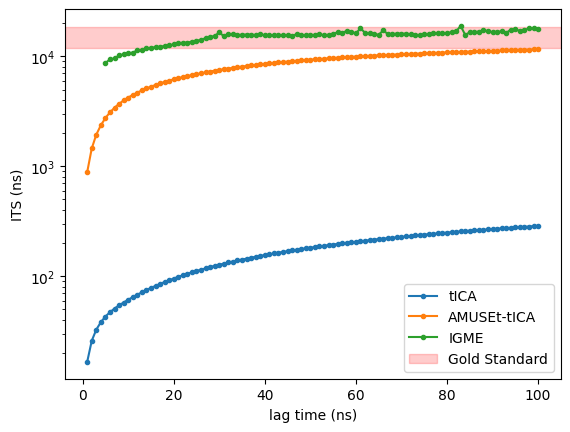

Current date and time: 2026-02-27 14:21:49.011586


In [37]:
ITS_AT = ITS

fig, ax = plt.subplots()
ax.set_yscale('log')
plt.xlabel("lag time (ns)")
plt.ylabel("ITS (ns)")

time_len = 100
ax.plot(range(1,time_len+1), ITS_tICA[0][:time_len], '.-', label='tICA')
ax.plot(range(1,time_len+1), ITS_AT[0][:time_len], '.-', label='AMUSEt-tICA')
ax.plot(range(5,time_len+1), ITS_IGME[0][:time_len-4], '.-', label='IGME') 
y_max, y_min = 18670.1, 11849.1
plt.axhspan(y_min, y_max, color='red', alpha=0.2, label='Gold Standard')

plt.legend()
plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

In [38]:
usage_ITS='''
fig, ax = plt.subplots()
ax.set_yscale('log')
plt.xlabel("lag time (ns)")
plt.ylabel("ITS (ns)")

time_len = 100
ax.plot(range(1,time_len+1), ITS_tICA[0][:time_len], '.-', label='tICA')
ax.plot(range(1,time_len+1), ITS_AT[0][:time_len], '.-', label='AMUSEt-tICA')
ax.plot(range(5,time_len+1), ITS_IGME[0][:time_len-4], '.-', label='IGME') 
y_max, y_min = 18670.1, 11849.1
plt.axhspan(y_min, y_max, color='red', alpha=0.2, label='Gold Standard')

plt.legend()
plt.show()
'''
np.savez('Panel_1d_ITS.npz', ITS_tICA=ITS_tICA, ITS_AT=ITS_AT, ITS_IGME=ITS_IGME, usage=usage_ITS)

In [39]:
np.load('Panel_1d_ITS.npz')

NpzFile 'Panel_1d_ITS.npz' with keys: ITS_tICA, ITS_AT, ITS_IGME, usage